In [6]:
import sys, os
sys.path.append(os.path.abspath("../src/"))
from importlib import reload
from sklearn.linear_model import LinearRegression

from hälsostudie import HealthAnalyzer






In [7]:

analyzer = HealthAnalyzer()

statistics = analyzer.descriptive_stats()
print(statistics)






               Mean  Median    Min     Max
age           49.43   50.00   18.0   90.00
weight        73.41   73.20   33.7  114.40
height       171.85  171.35  144.4  200.40
systolic_bp  149.18  149.40  106.8  185.90
cholesterol    4.93    4.97    2.5    7.88


### Medelvikt per kön

sex
F    67.20
M    79.72
Name: weight, dtype: float64


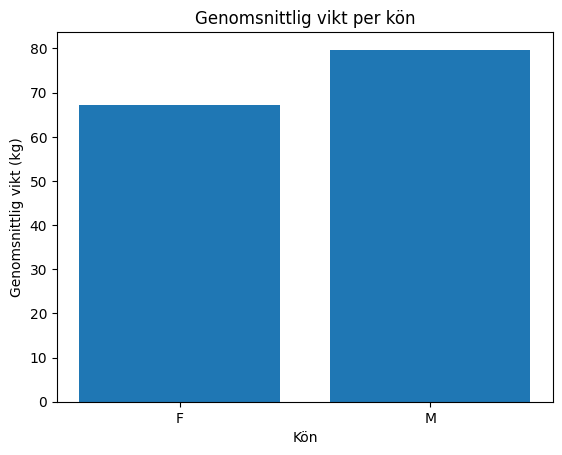

In [8]:
avg_weight = analyzer.avg_weight_by_gender()
print(avg_weight)


analyzer.plot_avg_weight_by_gender()

### AGe vs BP

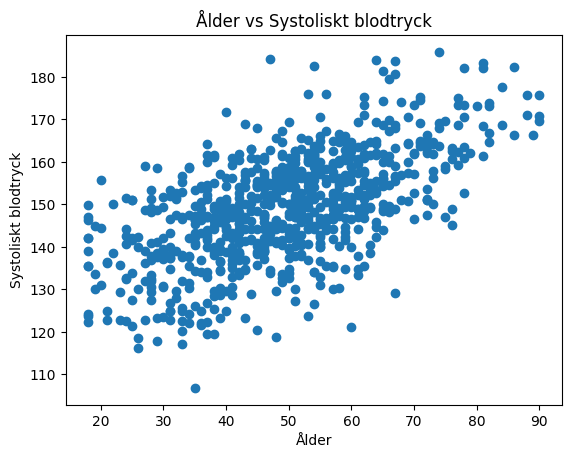

In [9]:
analyzer.plot_age_vs_bp()

Intercept: 122.68
Slope: 0.54

Model: BP = age * slope + intercept


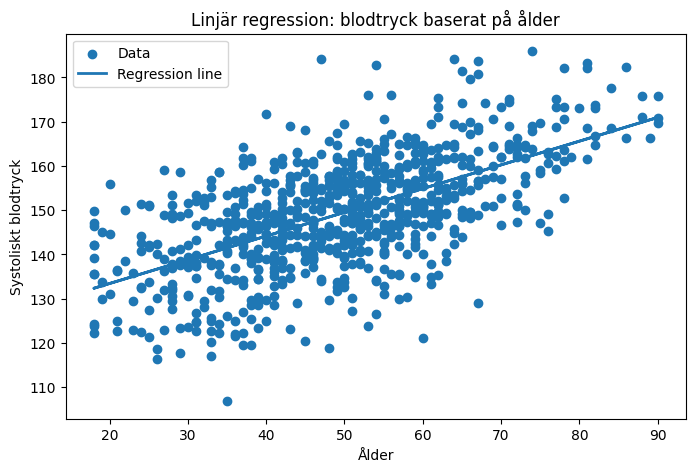

In [10]:
analyzer.regression_bp_age()



In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv('..\\data\\health_study_dataset.csv')  # Replace with your file path

# Encode categorical variables
data['sex'] = data['sex'].map({'F': 0, 'M': 1})
data['smoker'] = data['smoker'].map({'No': 0, 'Yes': 1})

# Select numeric columns for PCA
features = ['age', 'sex', 'height', 'weight', 'systolic_bp', 'cholesterol', 'smoker']
X = data[features]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA (2 components for visualization)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['disease'] = data['disease']  # optional for coloring

# Scatter plot to visualize clusters/patterns
plt.figure(figsize=(8,6))
colors = ['blue' if d == 0 else 'red' for d in pca_df['disease']]
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=colors)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - First Two Components')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'your_dataset.csv'